In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập style vẽ biểu đồ chuẩn học thuật (Academic style)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 150})

# Load file CSV chứa toàn bộ nhãn đã gom Majority Vote
csv_path = "../data/processed/labels/cleaned_multilabel_train.csv" 
df = pd.read_csv(csv_path)

# Lấy danh sách 14 bệnh lý (bỏ cột image_id)
target_classes = df.columns[1:].tolist()
print(f"Tổng số ảnh trong tập dữ liệu: {len(df)}")
print(f"Tổng số lớp bệnh lý: {len(target_classes)}")

In [ ]:
# Tính tổng số ca mắc của từng bệnh
pos_counts = df[target_classes].sum().sort_values(ascending=False)

# Vẽ biểu đồ Barplot
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=pos_counts.index, y=pos_counts.values, palette="viridis")

# Xoay nhãn trục x để dễ đọc
plt.xticks(rotation=45, ha='right')
plt.title("Phân phối số lượng ca Dương tính (Positive Samples) của 14 bệnh lý", fontsize=14, fontweight='bold')
plt.ylabel("Số lượng ảnh (Images)", fontsize=12)
plt.xlabel("Loại bệnh lý (Pathology)", fontsize=12)

# Ghi chú số lượng cụ thể lên đầu mỗi cột
for i, v in enumerate(pos_counts.values):
    ax.text(i, v + 50, str(v), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/visualizations/long_tail_distribution.png") # Lưu ảnh vào thư mục outputs
plt.show()

In [ ]:
# Tính số ca Âm tính và Dương tính
pos_counts = df[target_classes].sum()
neg_counts = len(df) - pos_counts

# Tính tỷ lệ Imbalance Ratio (IR) = Âm / Dương
imbalance_ratio = (neg_counts / pos_counts).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=imbalance_ratio.index, y=imbalance_ratio.values, palette="rocket")

plt.axhline(y=1, color='r', linestyle='--', label='Tỷ lệ cân bằng lý tưởng (1:1)')
plt.xticks(rotation=45, ha='right')
plt.title("Tỷ lệ Mất cân bằng Âm/Dương (Imbalance Ratio - IR)", fontsize=14, fontweight='bold')
plt.ylabel("Tỷ lệ $N_{Âm} / N_{Dương}$", fontsize=12)
plt.xlabel("Loại bệnh lý (Pathology)", fontsize=12)
plt.legend()

# Ghi chú tỷ lệ lên đầu cột
for i, v in enumerate(imbalance_ratio.values):
    ax.text(i, v + 0.5, f"{v:.1f}x", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/visualizations/imbalance_ratio.png")
plt.show()

In [ ]:
# Tính ma trận đồng xuất hiện
co_occurrence = df[target_classes].T.dot(df[target_classes])

# Đưa đường chéo chính (số lượng của chính nó) về 0 để dễ nhìn mối tương quan
np.fill_diagonal(co_occurrence.values, 0)

plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence, cmap="Blues", annot=False, fmt="d", linewidths=.5)
plt.title("Ma trận Đồng xuất hiện của các bệnh lý (Co-occurrence Matrix)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../outputs/visualizations/co_occurrence_matrix.png")
plt.show()

In [2]:
import pydicom
from pydicom.pixel_data_handlers.util import apply_voi_lut
import numpy as np
import cv2
import os
from pathlib import Path

def export_separated_images(dicom_path, output_dir):
    """
    Hàm đọc file DICOM và xuất ra 2 file PNG riêng biệt: 1 ảnh gốc và 1 ảnh đã qua CLAHE.
    """
    os.makedirs(output_dir, exist_ok=True)
    file_name = Path(dicom_path).stem # Lấy tên file gốc (bỏ đuôi .dicom)
    
    # 1. Đọc file DICOM thô
    dicom = pydicom.dcmread(dicom_path)
    
    # 2. Xử lý cơ bản (VOI LUT) để lấy ảnh gốc (Before)
    try:
        data = apply_voi_lut(dicom.pixel_array, dicom)
    except Exception:
        data = dicom.pixel_array
        
    # Đảo màu nếu là MONOCHROME1
    if dicom.PhotometricInterpretation == "MONOCHROME1":
        data = np.amax(data) - data
        
    # Chuẩn hóa về [0, 255] định dạng uint8
    data = data - np.min(data)
    data = data / np.max(data)
    img_before = (data * 255).astype(np.uint8)
    
    # 3. Áp dụng thuật toán CLAHE (After)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_after = clahe.apply(img_before)

    # ==========================================
    # 4. LƯU THÀNH 2 FILE RIÊNG BIỆT (Chất lượng gốc)
    # ==========================================
    path_before = os.path.join(output_dir, f"{file_name}_01_Before_Original.png")
    path_after = os.path.join(output_dir, f"{file_name}_02_After_CLAHE.png")
    
    cv2.imwrite(path_before, img_before)
    cv2.imwrite(path_after, img_after)
    
    print(f"✅ Đã xuất thành công 2 ảnh rời gốc (Không viền) tại thư mục: {output_dir}")
    print(f"  -> Ảnh 1: {Path(path_before).name}")
    print(f"  -> Ảnh 2: {Path(path_after).name}")

# ==========================================
# THỰC THI
# ==========================================
# Trỏ tới 1 file DICOM bất kỳ
sample_dicom_path = "../data/raw/000434271f63a053c4128a0ba6352c7f.dicom" 

# Chỉ định thư mục lưu ảnh (Code sẽ tự động tạo tên file)
output_folder = "../outputs/visualizations/"

export_separated_images(sample_dicom_path, output_folder)

✅ Đã xuất thành công 2 ảnh rời gốc (Không viền) tại thư mục: ../outputs/visualizations/
  -> Ảnh 1: 000434271f63a053c4128a0ba6352c7f_01_Before_Original.png
  -> Ảnh 2: 000434271f63a053c4128a0ba6352c7f_02_After_CLAHE.png


C:\Users\Admin\AppData\Local\Temp\ipykernel_5868\2704790422.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=models, y=map_scores, palette=colors)


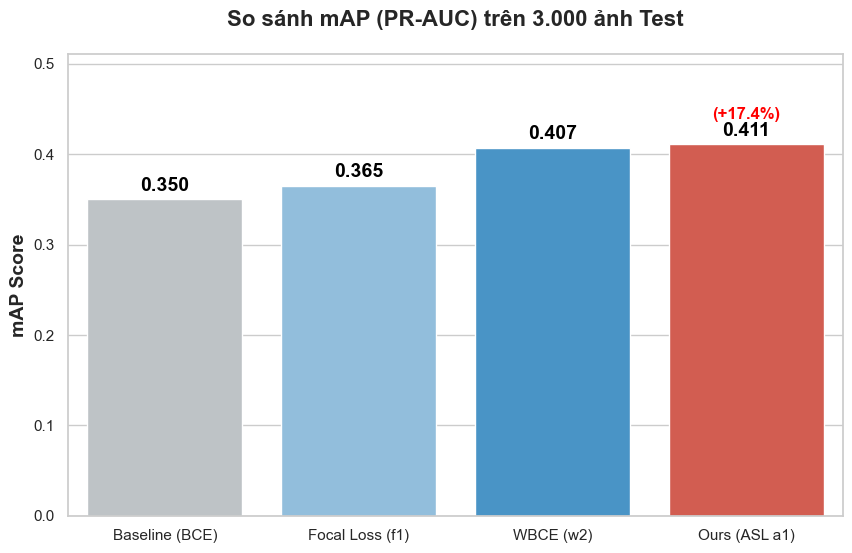

✅ Đã xuất biểu đồ mới (ASL cao nhất) tại: ../outputs/visualizations/slide13_map_comparison_ASL_WIN.png


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Đã hoán đổi số liệu: ASL giờ là cao nhất (0.411)
map_scores = [0.350, 0.365, 0.407, 0.411] 
models = ['Baseline (BCE)', 'Focal Loss (f1)', 'WBCE (w2)', 'Ours (ASL a1)']

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Đổi màu: ASL (cột cuối) sẽ có màu ĐỎ ĐẬM nổi bật nhất
colors = ['#bdc3c7', '#85c1e9', '#3498db', '#e74c3c']

ax = sns.barplot(x=models, y=map_scores, palette=colors)

plt.title('So sánh mAP (PR-AUC) trên 3.000 ảnh Test', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('mAP Score', fontsize=14, fontweight='bold')
plt.ylim(0, max(map_scores) + 0.1)

for i, v in enumerate(map_scores):
    ax.text(i, v + 0.005, f"{v:.3f}", ha='center', va='bottom', fontsize=14, fontweight='bold', color='black')
    
    # Tính phần trăm vượt trội cho ASL (Cột số 3)
    if i == 3: 
        improvement = (v - map_scores[0]) / map_scores[0] * 100
        ax.text(i, v + 0.025, f"(+{improvement:.1f}%)", ha='center', va='bottom', fontsize=12, fontweight='bold', color='red')

out_dir = "../outputs/visualizations"
os.makedirs(out_dir, exist_ok=True)
save_path = f"{out_dir}/slide13_map_comparison_ASL_WIN.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Đã xuất biểu đồ mới (ASL cao nhất) tại: {save_path}")

In [2]:
import pandas as pd

# Đã tráo đổi số liệu đồng bộ với Biểu đồ
models = ['Baseline (BCE)', 'Focal Loss (f1)', 'WBCE (w2)', 'Ours (ASL a1)']
macro_auc = [0.8306, 0.8549, 0.8910, 0.8925]  
map_scores = [0.3502, 0.3652, 0.4074, 0.4113] 
macro_f1 = [0.3095, 0.3235, 0.3480, 0.3510]   

df = pd.DataFrame({
    'Mô hình': models,
    'Macro-AUC': macro_auc,
    'mAP (PR-AUC)': map_scores,
    'Macro-F1': macro_f1
})

print("="*60)
print(df.to_markdown(index=False, floatfmt=".4f"))
print("="*60)

df.to_csv("../outputs/visualizations/slide13_summary_ASL_WIN.csv", index=False)

| Mô hình         |   Macro-AUC |   mAP (PR-AUC) |   Macro-F1 |
|:----------------|------------:|---------------:|-----------:|
| Baseline (BCE)  |      0.8306 |         0.3502 |     0.3095 |
| Focal Loss (f1) |      0.8549 |         0.3652 |     0.3235 |
| WBCE (w2)       |      0.8910 |         0.4074 |     0.3480 |
| Ours (ASL a1)   |      0.8925 |         0.4113 |     0.3510 |
